
# Two-Layer EBM with Sea-Ice Albedo Feedback
### Atmosphere · Ocean · Sea ice

This notebook keeps the same simple two-layer energy-balance structure as the earlier
model, but adds a temperature-dependent sea-ice albedo so the planetary albedo is no
longer fixed. The aim is to capture the main ice-albedo feedback without building a full
3D climate model.

The atmosphere still obeys a grey-body longwave budget, with OLR proportional to
$\epsilon(\mathrm{CO_2})\sigma T_a^4$, and the ocean remains a single heat reservoir.
A smooth sea-ice fraction adds a climate-state-dependent reflectivity.


In [1]:

%matplotlib inline
import pathlib
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from ipywidgets import interact, FloatSlider, IntSlider, Dropdown
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})


In [2]:
# Physical constants
S0 = 1361.0
S = S0 / 4.0
SIGMA = 5.670374419e-8

T0 = 288.15
CO2_0 = 280.0
K_CO2 = 5.35

alpha_open = 0.30
alpha_ice = 0.65
T_ice = 273.15
ICE_SLOPE = 8.0

OLR0 = S * (1.0 - alpha_open)
EPS0 = OLR0 / (SIGMA * T0**4)

RHO_W = 1025.0
CP_W = 3990.0
F_OCEAN = 0.71
CP_AIR = 1004.0
P_SURF = 1.01325e5
G_GRAV = 9.81
SEC_PER_YR = 3.1557e7
OCEAN_DEPTH = 3700.0


def ocean_layer_C(depth_m, f_ocean=F_OCEAN):
    """Heat capacity per square meter for a slab ocean layer.

    For a layer of depth d, the thermal mass is

        C_o = rho_w * c_p,w * d * f_ocean / (1 year)

    in units of W.yr m^-2 K^-1.
    """
    return RHO_W * CP_W * depth_m * f_ocean / SEC_PER_YR


C_ATMOS = CP_AIR * P_SURF / G_GRAV / SEC_PER_YR
C_OCEAN = ocean_layer_C(OCEAN_DEPTH)
GAMMA_AO = 10.0
B_PLANCK = 4 * EPS0 * SIGMA * T0**3

print(f'Pre-industrial OLR = {OLR0:.3f} W/m2  -> eps0 = {EPS0:.4f}')
print(f'Planck feedback at T0: 4*eps0*sigma*T0^3 = {B_PLANCK:.3f} W/m2/K')
print(f'Heat capacities [W.yr/m2/K]:  C_a = {C_ATMOS:.3f}  C_o = {C_OCEAN:.1f}')
print(f'Reference temperature T0 = {T0:.2f} K')


Pre-industrial OLR = 238.175 W/m2  -> eps0 = 0.6093
Planck feedback at T0: 4*eps0*sigma*T0^3 = 3.306 W/m2/K
Heat capacities [W.yr/m2/K]:  C_a = 0.329  C_o = 340.5
Reference temperature T0 = 288.15 K


In [3]:
# Real CO2 data, replacing the earlier synthetic linear-ramp + quadratic-fit
# approximation:
#
#   1850-1978 : Meinshausen et al. (2017) / CMIP6 historical GHG
#               concentrations (RCMIP "historical" series).
#   1979-2023 : NOAA GML observed global annual-mean CO2 -- real
#               measurements, not a reconstruction.
#   2024-2100 : RCMIP/CMIP6 SSP concentration pathway for the chosen
#               scenario (SSP1-2.6 / SSP2-4.5 / SSP5-8.5), offset-anchored
#               to the actual 2023 observed value so each projection
#               continues smoothly from real data instead of jumping to
#               RCMIP's (decade-old, slightly higher) projected 2023 value.
#
# See data/co2_historical_1850_2023.csv and data/co2_ssp_scenarios_2024_2100.csv
# (built from https://zenodo.org/records/4589756 and
# https://gml.noaa.gov/ccgg/trends/gl_data.html).
DATA_DIR = None
for _candidate in [pathlib.Path("data"), pathlib.Path("../data")]:
    if (_candidate / "co2_historical_1850_2023.csv").exists():
        DATA_DIR = _candidate
        break
if DATA_DIR is None:
    raise FileNotFoundError(
        "Could not find data/co2_historical_1850_2023.csv -- run this notebook "
        "from the 'code' directory it lives in (or alongside a sibling 'data' folder)."
    )

SSP_SCENARIOS = ['ssp126', 'ssp245', 'ssp585']

def _load_co2_data():
    hist = np.genfromtxt(DATA_DIR / 'co2_historical_1850_2023.csv', delimiter=',', skip_header=1)
    ssp = np.genfromtxt(DATA_DIR / 'co2_ssp_scenarios_2024_2100.csv', delimiter=',', skip_header=1)
    hist_years, hist_ppm = hist[:, 0], hist[:, 1]
    ssp_years = ssp[:, 0]
    ssp_cols = {'ssp126': ssp[:, 1], 'ssp245': ssp[:, 2], 'ssp585': ssp[:, 3]}

    years_by_scenario, ppm_by_scenario = {}, {}
    for name in SSP_SCENARIOS:
        years_by_scenario[name] = np.concatenate([hist_years, ssp_years])
        ppm_by_scenario[name] = np.concatenate([hist_ppm, ssp_cols[name]])
    return years_by_scenario, ppm_by_scenario

_CO2_YEARS, _CO2_PPM = _load_co2_data()


def co2_ppm(t, scenario='ssp245'):
    if scenario == 'none':
        return CO2_0
    return np.interp(t, _CO2_YEARS[scenario], _CO2_PPM[scenario])


def co2_forcing(t, scenario='ssp245'):
    """CO2 forcing from the standard logarithmic expression.

    The forcing is

        F_CO2 = K_CO2 * ln(CO2 / CO2_0)

    which is used here mainly as the physical basis for a greenhouse-opacity parameterization.
    """
    if scenario == 'none':
        return 0.0
    return K_CO2 * np.log(co2_ppm(t, scenario=scenario) / CO2_0)


def emissivity(CO2):
    """Effective grey-body emissivity of the atmosphere.

    The outgoing longwave radiation is represented as

        OLR = eps(CO2) * sigma * T_a^4

    and the effective emissivity is parameterized as

        eps(CO2) = eps_0 - K_CO2 * ln(CO2 / CO2_0) / (sigma * T_0^4)

    This captures the greenhouse effect in a compact, low-order manner.
    """
    return EPS0 - K_CO2 * np.log(CO2 / CO2_0) / (SIGMA * T0**4)


In [4]:

def sai_delta_alpha(t, d_alpha=0.0, start_year=2030, ramp_years=10, d_alpha_slope=0.0):
    """Simple prescribed albedo offset for SAI deployment.

    The offset is a linear ramp-up from zero to a target value, followed by an optional
    small long-term drift:

        Delta alpha_SAI = 0                                     if t < start_year
                        = d_alpha * (t - start_year) / ramp_years  if start_year <= t < ramp_end
                        = d_alpha + d_alpha_slope * (t - ramp_end) if t >= ramp_end
    """
    if d_alpha == 0.0 or t < start_year:
        return 0.0
    ramp_end = start_year + ramp_years
    if t < ramp_end:
        return d_alpha * (t - start_year) / ramp_years
    return d_alpha + d_alpha_slope * (t - ramp_end)


def sea_ice_fraction(T, T_ice=T_ice, k_ice=ICE_SLOPE):
    """Smooth sea-ice fraction as a function of temperature.

    The logistic form

        f_ice(T) = 1 / (1 + exp[k_ice * (T - T_ice)])

    transitions from near 1 in cold conditions to near 0 in warm conditions. This gives a
    simple representation of sea-ice growth and retreat without a full latitudinal model.
    """
    T = np.asarray(T, dtype=float)
    return 1.0 / (1.0 + np.exp(k_ice * (T - T_ice)))


def planetary_albedo(T, d_alpha=0.0, alpha_open=alpha_open, alpha_ice=alpha_ice,
                     T_ice=T_ice, k_ice=ICE_SLOPE):
    """Total planetary albedo including sea ice and SAI.

    We write

        alpha(T) = alpha_open + f_ice(T) * (alpha_ice - alpha_open) + Delta alpha_SAI

    with a smooth sea-ice fraction and a small prescribed brightening offset.
    """
    f_ice = sea_ice_fraction(T, T_ice=T_ice, k_ice=k_ice)
    alpha = alpha_open + f_ice * (alpha_ice - alpha_open) + d_alpha
    return np.clip(alpha, 0.0, 1.0)

# Sanity checks
assert np.allclose(planetary_albedo(T0, d_alpha=0.0), alpha_open, atol=1e-8)
assert 0.0 <= planetary_albedo(T0, d_alpha=0.0) <= 1.0
assert 0.0 <= sea_ice_fraction(T0).item() <= 1.0
print('Verification check: Sea-ice albedo setup valid: albedo at T0 is baseline, and ice fraction stays in [0,1].')


Sea-ice albedo setup valid: albedo at T0 is baseline, and ice fraction stays in [0,1].


In [5]:

def net_toa_imbalance(t, Ta, To, d_alpha=0.0, scenario='ssp245',
                     sai_start=2030, sai_ramp=10, d_alpha_slope=0.0,
                     alpha_open=alpha_open, alpha_ice=alpha_ice,
                     T_ice=T_ice, k_ice=ICE_SLOPE):
    """Net top-of-atmosphere radiative imbalance.

    The atmosphere gains or loses energy according to

        Q = S * (1 - alpha(T_o, t)) - eps(CO2(t)) * sigma * T_a^4

    with alpha depending on the sea-ice fraction and SAI offset.
    """
    alpha = planetary_albedo(
        To,
        d_alpha=sai_delta_alpha(t, d_alpha=d_alpha, start_year=sai_start,
                                ramp_years=sai_ramp, d_alpha_slope=d_alpha_slope),
        alpha_open=alpha_open,
        alpha_ice=alpha_ice,
        T_ice=T_ice,
        k_ice=k_ice,
    )
    eps = emissivity(co2_ppm(t, scenario=scenario))
    return S * (1.0 - alpha) - eps * SIGMA * Ta**4


def layer_derivs(t, y, C_a, C_o, gamma_ao, d_alpha=0.0, scenario='ssp245',
                 sai_start=2030, sai_ramp=10, d_alpha_slope=0.0,
                 alpha_open=alpha_open, alpha_ice=alpha_ice,
                 T_ice=T_ice, k_ice=ICE_SLOPE):
    """Right-hand side of the two-layer EBM.

    The state is [T_a, T_o], and the coupled equations are

        C_a dT_a/dt = S(1 - alpha(T_o, t)) - eps(CO2(t)) sigma T_a^4 - gamma_ao (T_a - T_o)
        C_o dT_o/dt = gamma_ao (T_a - T_o)

    so the atmosphere and ocean are coupled by a simple exchange term.
    """
    Ta, To = y
    alpha = planetary_albedo(
        To,
        d_alpha=sai_delta_alpha(t, d_alpha=d_alpha, start_year=sai_start,
                                ramp_years=sai_ramp, d_alpha_slope=d_alpha_slope),
        alpha_open=alpha_open,
        alpha_ice=alpha_ice,
        T_ice=T_ice,
        k_ice=k_ice,
    )
    eps = emissivity(co2_ppm(t, scenario=scenario))
    net_flux = S * (1.0 - alpha) - eps * SIGMA * Ta**4
    heat_exchange = gamma_ao * (Ta - To)
    return [(net_flux - heat_exchange) / C_a, heat_exchange / C_o]


def run_ebm(C_a=C_ATMOS, C_o=C_OCEAN, gamma_ao=GAMMA_AO, scenario='ssp245',
            d_alpha=0.0, sai_start=2030, sai_ramp=10, d_alpha_slope=0.0,
            alpha_open=alpha_open, alpha_ice=alpha_ice, T_ice=T_ice, k_ice=ICE_SLOPE,
            t_span=(1850, 2100), n_pts=2400):
    """Integrate the coupled system across a chosen time interval."""
    kw = dict(d_alpha=d_alpha, scenario=scenario, sai_start=sai_start,
              sai_ramp=sai_ramp, d_alpha_slope=d_alpha_slope,
              alpha_open=alpha_open, alpha_ice=alpha_ice, T_ice=T_ice, k_ice=k_ice)
    t_eval = np.linspace(*t_span, n_pts)
    sol = solve_ivp(lambda t, y: layer_derivs(t, y, C_a, C_o, gamma_ao, **kw),
                    t_span, [T0, T0], t_eval=t_eval, method='BDF', rtol=1e-8, atol=1e-10)
    Ta, To = sol.y
    Q = np.array([net_toa_imbalance(ti, Ta_i, To_i, **kw) for ti, Ta_i, To_i in zip(sol.t, Ta, To)])
    return sol.t, Ta, To, Q

# Baseline equilibrium check
baseline_Q = net_toa_imbalance(1850, T0, T0, scenario='none')
print(f'Baseline equilibrium check at T0: net TOA imbalance = {baseline_Q:.6f} W/m2')
if abs(baseline_Q) > 1e-6:
    raise ValueError('The baseline state is not in equilibrium; check the albedo and emissivity calibration.')


Baseline equilibrium check at T0: net TOA imbalance = 0.000000 W/m2


## Sea-ice feedback in the simple two-layer model

The model keeps the same atmosphere-ocean structure as before, but replaces the fixed
planetary albedo with a temperature-dependent value:

$$
\alpha(T_o) =
\alpha_{\mathrm{open}}
+ f_{\mathrm{ice}}(T_o)
\left(\alpha_{\mathrm{ice}} - \alpha_{\mathrm{open}}\right)
+ \Delta\alpha_{\mathrm{SAI}}(t)
$$

with a logistic sea-ice fraction

$$
f_{\mathrm{ice}}(T_o) =
\frac{1}{1 + \exp\left[k(T_o - T_{\mathrm{ice}})\right]}
$$

This gives a smooth albedo transition: warming reduces sea ice and reflectivity, while cooling
expands sea ice and increases reflectivity.

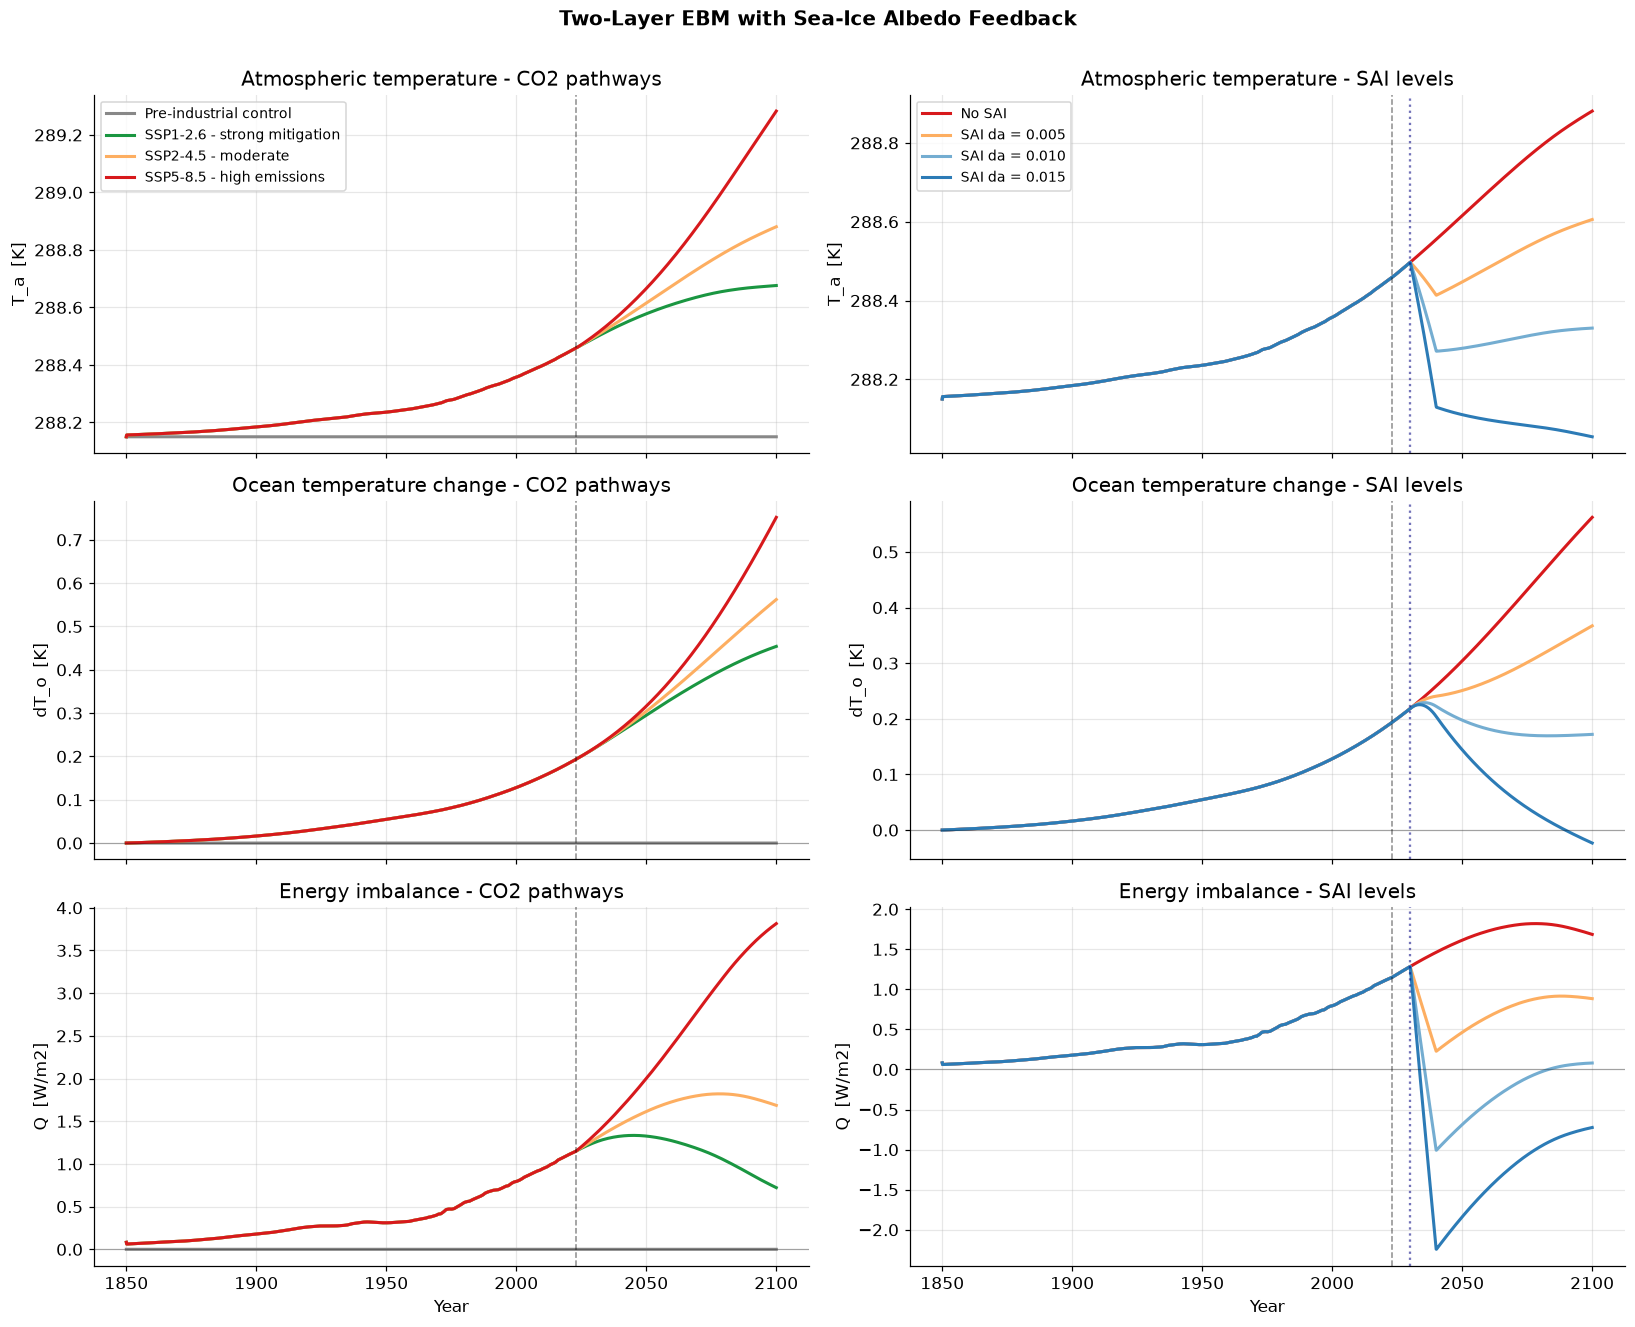

In [6]:

# Scenario comparison
fig, axes = plt.subplots(3, 2, figsize=(15, 12), sharex=True)
fig.suptitle('Two-Layer EBM with Sea-Ice Albedo Feedback', fontsize=13, fontweight='bold', y=1.003)

co2_cases = [
    ('none', 'Pre-industrial control', '#888888'),
    ('ssp126', 'SSP1-2.6 - strong mitigation', '#1a9641'),
    ('ssp245', 'SSP2-4.5 - moderate', '#fdae61'),
    ('ssp585', 'SSP5-8.5 - high emissions', '#d7191c'),
]
for scen, label, color in co2_cases:
    t, Ta, To, Q = run_ebm(scenario=scen, d_alpha=0.0)
    axes[0, 0].plot(t, Ta, color=color, lw=2, label=label)
    axes[1, 0].plot(t, To - T0, color=color, lw=2, label=label)
    axes[2, 0].plot(t, Q, color=color, lw=2, label=label)

sai_cases = [
    (0.000, 'No SAI', '#d7191c'),
    (0.005, 'SAI da = 0.005', '#fdae61'),
    (0.010, 'SAI da = 0.010', '#74add1'),
    (0.015, 'SAI da = 0.015', '#2c7bb6'),
]
for da, label, color in sai_cases:
    t, Ta, To, Q = run_ebm(scenario='ssp245', d_alpha=da)
    axes[0, 1].plot(t, Ta, color=color, lw=2, label=label)
    axes[1, 1].plot(t, To - T0, color=color, lw=2, label=label)
    axes[2, 1].plot(t, Q, color=color, lw=2, label=label)

for ax in axes.flat:
    ax.axvline(2023, color='k', ls='--', lw=1, alpha=0.45)
for ax in axes[:, 1]:
    ax.axvline(2030, color='navy', ls=':', lw=1.5, alpha=0.55)
for ax in list(axes[1, :]) + list(axes[2, :]):
    ax.axhline(0, color='k', lw=0.8, alpha=0.3)

axes[0, 0].set(title='Atmospheric temperature - CO2 pathways', ylabel='T_a  [K]')
axes[0, 1].set(title='Atmospheric temperature - SAI levels', ylabel='T_a  [K]')
axes[1, 0].set(title='Ocean temperature change - CO2 pathways', ylabel='dT_o  [K]')
axes[1, 1].set(title='Ocean temperature change - SAI levels', ylabel='dT_o  [K]')
axes[2, 0].set(title='Energy imbalance - CO2 pathways', ylabel='Q  [W/m2]', xlabel='Year')
axes[2, 1].set(title='Energy imbalance - SAI levels', ylabel='Q  [W/m2]', xlabel='Year')

axes[0, 0].legend(fontsize=9)
axes[0, 1].legend(fontsize=9)

plt.tight_layout(); plt.show()



## Interactive exploration

Adjust the sea-ice properties, the coupling strength, and the SAI schedule to see how the
albedo feedback interacts with greenhouse forcing.


In [7]:

def plot_ice_model(C_o, gamma_ao, scenario, d_alpha, sai_start, sai_ramp, d_alpha_slope,
                  alpha_open, alpha_ice, T_ice, ice_slope):
    t_base, Ta_base, To_base, Q_base = run_ebm(C_o=C_o, gamma_ao=gamma_ao, scenario=scenario,
                                              d_alpha=0.0, alpha_open=alpha_open,
                                              alpha_ice=alpha_ice, T_ice=T_ice, k_ice=ice_slope)
    t_sai, Ta_sai, To_sai, Q_sai = run_ebm(C_o=C_o, gamma_ao=gamma_ao, scenario=scenario,
                                           d_alpha=d_alpha, sai_start=sai_start,
                                           sai_ramp=sai_ramp, d_alpha_slope=d_alpha_slope,
                                           alpha_open=alpha_open, alpha_ice=alpha_ice,
                                           T_ice=T_ice, k_ice=ice_slope)

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.subplots_adjust(hspace=0.35, wspace=0.25)
    fig.suptitle(f'Two-Layer EBM with ice albedo | {scenario.upper()} | C_o={C_o:.0f}, gamma_ao={gamma_ao:.2f}', fontsize=12, fontweight='bold')

    ax = axes[0, 0]
    ax.plot(t_base, Ta_base, color='#d7191c', lw=2, label='No SAI')
    ax.plot(t_sai, Ta_sai, color='#2c7bb6', lw=2, label='With SAI')
    ax.axvline(2023, color='k', ls='--', lw=1, alpha=0.4)
    ax.set(title='Atmospheric temperature', ylabel='T_a  [K]', xlabel='Year')
    ax.legend(fontsize=8)

    ax = axes[0, 1]
    ax.plot(t_base, To_base - T0, color='#d7191c', lw=2, label='Ocean warming, no SAI')
    ax.plot(t_sai, To_sai - T0, color='#2c7bb6', lw=2, label='Ocean warming, SAI')
    ax2 = ax.twinx()
    ice_sai = sea_ice_fraction(To_sai, T_ice=T_ice, k_ice=ice_slope)
    ax2.plot(t_sai, ice_sai, color='#01665e', lw=2, ls='--', label='Sea-ice fraction')
    ax2.set_ylabel('Sea-ice fraction  f_ice  [-]')
    ax2.grid(False)
    ax.set(title='Ocean temperature change', ylabel='dT_o  [K]', xlabel='Year')
    ax.axhline(0, color='k', lw=0.8, alpha=0.4)
    ax.legend(fontsize=8)

    ax = axes[1, 0]
    ax.plot(t_base, Q_base, color='#d7191c', lw=2, label='Q, no SAI')
    ax.plot(t_sai, Q_sai, color='#2c7bb6', lw=2, label='Q, SAI')
    ax.axhline(0, color='k', lw=0.8, alpha=0.4)
    ax.set(title='Energy imbalance', ylabel='Q  [W/m2]', xlabel='Year')
    ax.legend(fontsize=8)

    ax = axes[1, 1]
    alpha_base = np.array([planetary_albedo(To_i, d_alpha=0.0, alpha_open=alpha_open,
                                           alpha_ice=alpha_ice, T_ice=T_ice, k_ice=ice_slope)
                           for To_i in To_base])
    alpha_sai = np.array([planetary_albedo(To_i, d_alpha=sai_delta_alpha(ti, d_alpha=d_alpha,
                                                                         start_year=sai_start,
                                                                         ramp_years=sai_ramp,
                                                                         d_alpha_slope=d_alpha_slope),
                                           alpha_open=alpha_open, alpha_ice=alpha_ice,
                                           T_ice=T_ice, k_ice=ice_slope)
                          for ti, To_i in zip(t_sai, To_sai)])
    ax.plot(t_base, alpha_base, color='#d7191c', lw=2, label='alpha, no SAI')
    ax.plot(t_sai, alpha_sai, color='#2c7bb6', lw=2, label='alpha, SAI')
    ax.axhline(alpha_open, color='k', lw=1, ls=':', alpha=0.5, label='alpha_open')
    ax.axhline(alpha_ice, color='gray', lw=1, ls=':', alpha=0.5, label='alpha_ice')
    ax.set(title='Planetary albedo', ylabel='alpha  [-]', xlabel='Year')
    ax.legend(fontsize=8)

    plt.tight_layout(); plt.show()

interact(
    plot_ice_model,
    C_o=FloatSlider(value=C_OCEAN, min=50.0, max=700.0, step=10.0, description='C_o [W.yr/m2/K]', style={'description_width': 'initial'}),
    gamma_ao=FloatSlider(value=GAMMA_AO, min=0.5, max=20.0, step=0.5, description='gamma_ao [W/m2/K]', style={'description_width': 'initial'}, readout_format='.2f'),
    scenario=Dropdown(options=['none', 'ssp126', 'ssp245', 'ssp585'], value='ssp245', description='CO2 scenario'),
    d_alpha=FloatSlider(value=0.0, min=0.0, max=0.015, step=0.0005, description='SAI da', style={'description_width': 'initial'}, readout_format='.4f'),
    sai_start=IntSlider(value=2030, min=2025, max=2080, step=5, description='SAI start year', style={'description_width': 'initial'}),
    sai_ramp=IntSlider(value=10, min=1, max=30, step=1, description='Ramp-up years', style={'description_width': 'initial'}),
    d_alpha_slope=FloatSlider(value=0.0, min=0.0, max=0.00025, step=0.000005, description='Post-ramp slope (da/yr)', style={'description_width': 'initial'}, readout_format='.5f'),
    alpha_open=FloatSlider(value=0.30, min=0.15, max=0.45, step=0.01, description='alpha_open', style={'description_width': 'initial'}, readout_format='.2f'),
    alpha_ice=FloatSlider(value=0.65, min=0.40, max=0.85, step=0.01, description='alpha_ice', style={'description_width': 'initial'}, readout_format='.2f'),
    T_ice=FloatSlider(value=273.15, min=268.0, max=278.0, step=0.25, description='T_ice [K]', style={'description_width': 'initial'}, readout_format='.2f'),
    ice_slope=FloatSlider(value=8.0, min=1.0, max=20.0, step=0.5, description='ice_slope', style={'description_width': 'initial'}, readout_format='.1f'),
)


interactive(children=(FloatSlider(value=340.456103241753, description='C_o [W.yr/m2/K]', max=700.0, min=50.0, …

<function __main__.plot_ice_model(C_o, gamma_ao, scenario, d_alpha, sai_start, sai_ramp, d_alpha_slope, alpha_open, alpha_ice, T_ice, ice_slope)>